# S&P 500 Global Optimization & Portfolio Backtest

In this notebook, we will:
1. Parse the entire **S&P 500 universe**.
2. Run a highly parallelized grid search on **every asset** testing different timeframes (1-Min, 5-Min) and parameters (Measurement Variances, Z-Scores, Windows).
3. Filter down to a **Global Top 20** assets using rigorous metrics (**Sharpe, Sortino, Alpha, Beta, Win Rate, Max Drawdown**).
4. Construct an **Equal-Weighted Portfolio** of these Top 20 strategies.
5. Backtest and visualize the overall Portfolio against the SPY benchmark.

In [11]:
!pip3 install lxml

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 8.6 MB 6.2 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [12]:
import os
import time
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Alpaca imports
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

warnings.filterwarnings('ignore')

# -------------------------------------------------------------
# Kalman Filter & Backtest Engine
# -------------------------------------------------------------
class SingleStateKalmanFilter:
    def __init__(self, process_variance, estimated_measurement_variance):
        self.process_variance = process_variance
        self.estimated_measurement_variance = estimated_measurement_variance
        self.posteri_estimate = 0.0
        self.posteri_error_estimate = 1.0

    def input_latest_measurement(self, measurement):
        priori_estimate = self.posteri_estimate
        priori_error_estimate = self.posteri_error_estimate + self.process_variance
        blending_factor = priori_error_estimate / (priori_error_estimate + self.estimated_measurement_variance)
        self.posteri_estimate = priori_estimate + blending_factor * (measurement - priori_estimate)
        self.posteri_error_estimate = (1 - blending_factor) * priori_error_estimate
        return self.posteri_estimate

def enhanced_kalman_backtest(prices_series, process_variance=1e-5, measurement_variance=1e-3, z_threshold=1.5, window=20):
    if len(prices_series) < window + 5:
        return pd.Series(0, index=prices_series.index), np.zeros(len(prices_series))
        
    kf = SingleStateKalmanFilter(process_variance, measurement_variance)
    kalman_means = []
    errors = []
    
    kf.posteri_estimate = prices_series.iloc[0]
    for p in prices_series:
        k = kf.input_latest_measurement(p)
        kalman_means.append(k)
        errors.append(p - k)
        
    df = prices_series.to_frame(name='price')
    df['error'] = errors
    df['error_std'] = df['error'].rolling(window=window).std()
    df['z_score'] = (df['error'] / df['error_std']).fillna(0)
    
    positions = np.zeros(len(df))
    z_scores = df['z_score'].values
    current_pos = 0
    
    for i in range(len(z_scores)):
        z = z_scores[i]
        if z > z_threshold and current_pos <= 0:
            current_pos = -1 
        elif z < -z_threshold and current_pos >= 0:
            current_pos = 1  
        elif current_pos == -1 and z < 0:
            current_pos = 0  
        elif current_pos == 1 and z > 0:
            current_pos = 0  
        positions[i] = current_pos
        
    df['position'] = positions
    # Shift position by 1 (trade on next bar)
    df['position'] = df['position'].shift(1).fillna(0)
    df['returns'] = df['position'] * df['price'].pct_change()
    
    return df['returns'].fillna(0), df['position']

def calculate_metrics(strat_returns, bench_returns):
    aligned = pd.concat([strat_returns.rename('strat'), bench_returns.rename('bench')], axis=1).fillna(0)
    strat = aligned['strat']
    bench = aligned['bench']
    
    total_ret = (1 + strat).prod() - 1
    cum_ret = (1 + strat).cumprod()
    
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    
    cov = np.cov(strat, bench)[0][1] if len(strat) > 1 else 0
    var = np.var(bench) if len(bench) > 1 else 0
    beta = cov / var if var != 0 else 0
    
    bench_ret = (1 + bench).prod() - 1
    alpha = total_ret - (beta * bench_ret)
    
    sharpe = (strat.mean() / strat.std()) * np.sqrt(len(strat)) if strat.std() != 0 else 0
    
    downside_returns = strat[strat < 0]
    sortino = (strat.mean() / downside_returns.std()) * np.sqrt(len(strat)) if len(downside_returns) > 0 and downside_returns.std() != 0 else 0
    
    active_trades = strat[strat != 0]
    win_rate = len(active_trades[active_trades > 0]) / len(active_trades) if len(active_trades) > 0 else 0
    
    return {
        'total_return': total_ret,
        'max_drawdown': max_dd,
        'beta': beta,
        'alpha': alpha,
        'sharpe': sharpe,
        'sortino': sortino,
        'win_rate': win_rate
    }

In [13]:
# -------------------------------------------------------------
# 1. Initialization and Data Fetching (Entire S&P 500)
# -------------------------------------------------------------
import requests
import io

load_dotenv('../.env')
API_KEY = os.getenv('ALPACA_API_KEY')
API_SECRET = os.getenv('ALPACA_API_SECRET')
client = StockHistoricalDataClient(API_KEY, API_SECRET)

print("Loading all S&P 500 Tickers from Wikipedia...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
try:
    response = requests.get(url, headers=headers, timeout=10)
    sp500_table = pd.read_html(io.StringIO(response.text))[0]
    tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
    print("Successfully pulled S&P 500 from Wikipedia.")
except Exception as e:
    print(f"Failed to pull S&P 500: {e}. Fallback to sample 50.")
    tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META']

print(f"Total tickers to process: {len(tickers)}")

# We will pull 14 days of 1-minute data 
end_time = datetime.now()
start_time = end_time - timedelta(days=14) 

# Fetch SPY Benchmark
print("Fetching SPY Benchmark...")
spy_req = StockBarsRequest(symbol_or_symbols=['SPY'], timeframe=TimeFrame.Minute, start=start_time, end=end_time)
spy_df = client.get_stock_bars(spy_req).df

# Batch Fetch All 500 in chunks to respect Alpaca rate limits and avoid pagination limits
chunk_size = 25  # Lowered from 50 to 25 to be ultra-safe on data payload limits
all_data = []

print("Fetching 1-Minute Data for the entire universe (14 Days). This will take a moment...")
for i in tqdm(range(0, len(tickers), chunk_size)):
    chunk = tickers[i:i+chunk_size]
    req = StockBarsRequest(symbol_or_symbols=chunk, timeframe=TimeFrame.Minute, start=start_time, end=end_time)
    try:
        df_c = client.get_stock_bars(req).df
        all_data.append(df_c)
    except Exception as e:
        print(f"Error fetching chunk starting with {chunk[0]}: {e}")
        pass
    time.sleep(0.5)
    
full_df = pd.concat(all_data) if all_data else pd.DataFrame()
if not full_df.empty:
    unique_syms = full_df.index.get_level_values(0).unique()
    print(f"Successfully downloaded {len(full_df)} rows for {len(unique_syms)} unique S&P 500 symbols.")
else:
    print("Failed to download any data.")

Loading all S&P 500 Tickers from Wikipedia...
Successfully pulled S&P 500 from Wikipedia.
Total tickers to process: 503
Fetching SPY Benchmark...
Fetching 1-Minute Data for the entire universe (14 Days). This will take a moment...


 10%|▉         | 2/21 [00:07<01:14,  3.90s/it]

Error fetching chunk starting with ADSK: {"message":"invalid symbol: BRK-B"}



 14%|█▍        | 3/21 [00:08<00:43,  2.39s/it]

Error fetching chunk starting with BRO: {"message":"invalid symbol: BF-B"}



100%|██████████| 21/21 [01:12<00:00,  3.47s/it]

Successfully downloaded 1901698 rows for 453 unique S&P 500 symbols.


In [14]:
# -------------------------------------------------------------
# 2. Global Parameter Grid Search
# -------------------------------------------------------------
process_vz = 1e-5
measurement_variances = [1e-3, 1e-2]
z_thresholds = [1.0, 1.5, 2.0]
windows = [10, 20]
grid = list(itertools.product(measurement_variances, z_thresholds, windows))

timeframes = {'1Min': '1min', '5Min': '5min'}
results = []

print("Running Global Grid Search on HFT parameters... (This will evaluate thousands of combinations)")

if not full_df.empty:
    for sym in tqdm(unique_syms):
        try:
            sym_data = full_df.loc[sym].sort_index()
        except KeyError:
            continue
            
        if len(sym_data) < 500: continue
            
        for tf_name, tf_rule in timeframes.items():
            res_close = sym_data['close'].resample(tf_rule).last().dropna()
            res_spy = spy_df.loc['SPY']['close'].resample(tf_rule).last().dropna().pct_change().dropna()
            
            best_sharpe = -100
            best_metrics, best_params = None, None
            
            for m_var, z_thresh, wd in grid:
                strat_rets, _ = enhanced_kalman_backtest(res_close, process_variance=process_vz, measurement_variance=m_var, z_threshold=z_thresh, window=wd)
                metrics = calculate_metrics(strat_rets, res_spy)
                
                if metrics['sharpe'] > best_sharpe:
                    best_sharpe = metrics['sharpe']
                    best_metrics = metrics
                    best_params = (m_var, z_thresh, wd)
                    
            if best_metrics and best_metrics['total_return'] > 0:
                results.append({
                    'symbol': sym,
                    'timeframe': tf_name,
                    'tf_rule': tf_rule,
                    'sharpe': best_metrics['sharpe'],
                    'sortino': best_metrics['sortino'],
                    'total_return_pct': best_metrics['total_return'] * 100,
                    'max_drawdown_pct': best_metrics['max_drawdown'] * 100,
                    'alpha_pct': best_metrics['alpha'] * 100,
                    'beta': best_metrics['beta'],
                    'win_rate': best_metrics['win_rate'],
                    'opt_m_var': best_params[0],
                    'opt_z_thresh': best_params[1],
                    'opt_window': best_params[2]
                })

    # Sort all global combinations by Sharpe Ratio to get the Best Risk-Adjusted Returns
    final_df = pd.DataFrame(results).sort_values(by='sharpe', ascending=False)
    final_df.to_csv('sp500_kalman_optimization_results.csv', index=False)

    print("\n--- GLOBAL TOP 15 ASSETS & CONFIGURATIONS ---")
    top_15 = final_df.head(15)
    display(top_15[['symbol', 'timeframe', 'sharpe', 'sortino', 'alpha_pct', 'max_drawdown_pct', 'win_rate', 'opt_m_var', 'opt_z_thresh', 'opt_window']])
else:
    print("Cannot run grid search: no data was downloaded.")
    top_15 = pd.DataFrame()

Running Global Grid Search on HFT parameters... (This will evaluate thousands of combinations)


100%|██████████| 453/453 [00:40<00:00, 11.08it/s]


--- GLOBAL TOP 15 ASSETS & CONFIGURATIONS ---


,symbol,timeframe,sharpe,sortino,alpha_pct,max_drawdown_pct,win_rate,opt_m_var,opt_z_thresh,opt_window
12,AES,1Min,12.078605,6.146286,35.925810,-0.636042,0.723940,0.001,1.0,10
554,NKE,1Min,7.364054,8.575365,63.628101,-2.140595,0.541039,0.001,1.0,20
681,NOW,1Min,6.382646,6.294587,100.823573,-6.239724,0.538444,0.001,1.0,10
50,AAPL,1Min,6.371945,6.458805,37.031958,-1.725314,0.539235,0.001,1.0,10
523,MSFT,1Min,5.845471,6.193218,35.562318,-2.813039,0.539043,0.001,1.0,10
550,NFLX,1Min,5.465300,5.184444,42.919992,-2.386649,0.544863,0.001,1.0,20
590,PANW,1Min,5.452217,4.585973,49.799484,-2.180995,0.544273,0.001,2.0,10
852,WMT,1Min,5.282768,4.592834,28.452778,-2.605112,0.530297,0.001,1.5,20
185,DVN,1Min,5.273674,4.688326,55.733571,-2.474682,0.537911,0.001,1.0,10
30,AMZN,1Min,5.246341,5.205052,40.807631,-2.255034,0.536750,0.001,1.0,10


Building Equal-Weighted Portfolio from the Top 15 distinct assets...
==== EQUAL-WEIGHTED PORTFOLIO METRICS ====
Total Return:   51.26%
Sharpe Ratio:   16.12
Sortino Ratio:  20.75
Max Drawdown:   -1.00%
Portfolio Beta: 0.0703
Portfolio Alpa: 51.48%
Win Rate:       60.20%


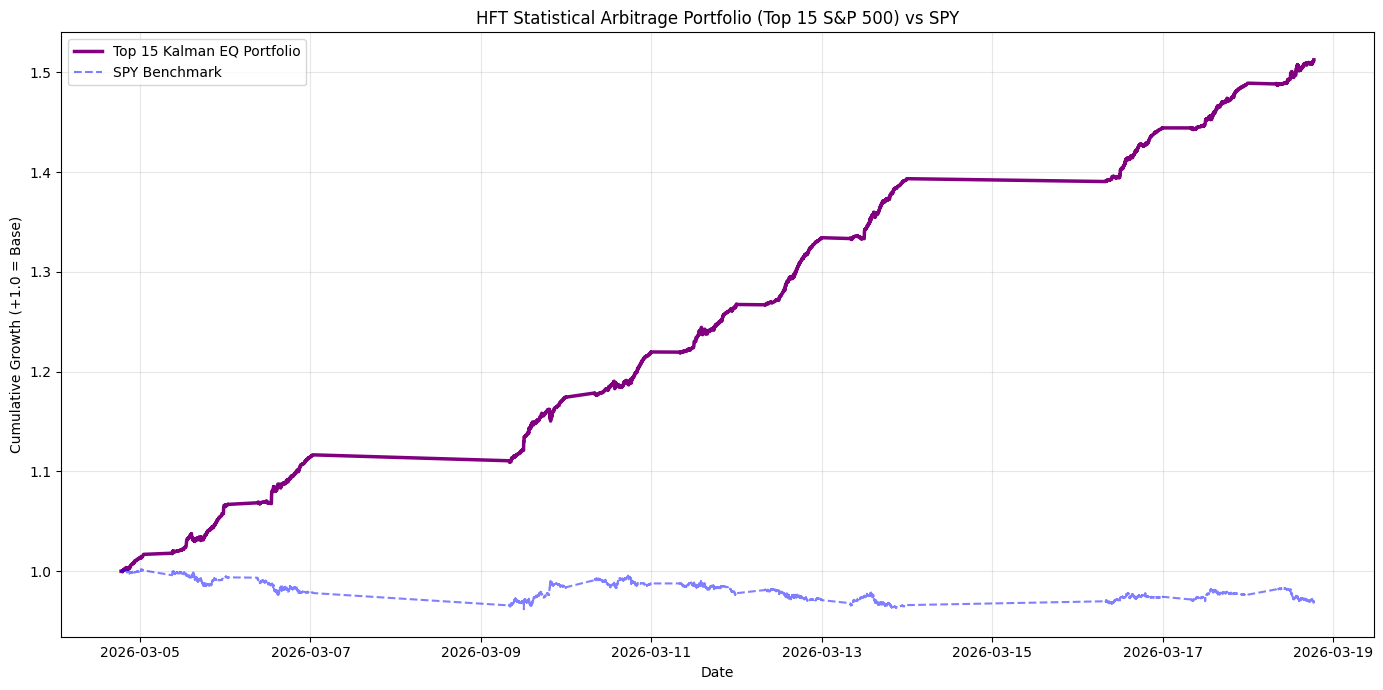

In [15]:
# -------------------------------------------------------------
# 3. Portfolio Construction & Backtest
# -------------------------------------------------------------
if not top_15.empty:
    print("Building Equal-Weighted Portfolio from the Top 15 distinct assets...")

    portfolio_returns = []

    # Fetch 1-min baseline SPY returns to benchmark the overall portfolio
    spy_1m_rets = spy_df.loc['SPY']['close'].pct_change().dropna()

    for _, row in top_15.iterrows():
        sym = row['symbol']
        tf_rule = row['tf_rule']
        m_var = row['opt_m_var']
        z_t = row['opt_z_thresh']
        wd = int(row['opt_window'])
        
        # Rerun the best strategy for this asset
        sym_data = full_df.loc[sym].sort_index()['close'].resample(tf_rule).last().dropna()
        strat_rets, _ = enhanced_kalman_backtest(
            sym_data, 
            process_variance=process_vz, 
            measurement_variance=m_var, 
            z_threshold=z_t, 
            window=wd
        )
        
        # We rename the series to the symbol name so we can concatenate them matrix-style
        portfolio_returns.append(strat_rets.rename(sym))

    # Combine all Strategy Returns into a single DataFrame aligned by Time
    # Ffillna handles mismatching timestamps between 1-Min and 5-Min strategies (carry forward flat returns)
    portfolio_df = pd.concat(portfolio_returns, axis=1).fillna(0)

    # Mean of axis=1 distributes capital equally across all 15 strategies at every timestamp
    equal_weight_portfolio_returns = portfolio_df.mean(axis=1)

    # Calculate Full Portfolio Metrics vs SPY
    port_metrics = calculate_metrics(equal_weight_portfolio_returns, spy_1m_rets)

    print("==== EQUAL-WEIGHTED PORTFOLIO METRICS ====")
    print(f"Total Return:   {port_metrics['total_return']*100:.2f}%")
    print(f"Sharpe Ratio:   {port_metrics['sharpe']:.2f}")
    print(f"Sortino Ratio:  {port_metrics['sortino']:.2f}")
    print(f"Max Drawdown:   {port_metrics['max_drawdown']*100:.2f}%")
    print(f"Portfolio Beta: {port_metrics['beta']:.4f}")
    print(f"Portfolio Alpa: {port_metrics['alpha']*100:.2f}%")
    print(f"Win Rate:       {port_metrics['win_rate']*100:.2f}%")

    # Visualize Portfolio Equity Curve
    cum_port = (1 + equal_weight_portfolio_returns).cumprod()
    cum_spy = (1 + spy_1m_rets).cumprod()

    plt.figure(figsize=(14, 7))
    plt.plot(cum_port, label=f"Top 15 Kalman EQ Portfolio", color='purple', linewidth=2.5)
    plt.plot(cum_spy, label="SPY Benchmark", color='blue', alpha=0.5, linestyle='--')
    plt.title("HFT Statistical Arbitrage Portfolio (Top 15 S&P 500) vs SPY")
    plt.ylabel("Cumulative Growth (+1.0 = Base)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot build portfolio: Top 15 data is empty.")